# 🔧 Day 25: GPU FinOps & Cost Optimization - Hands-on Lab

This notebook connects to a local Docker Compose cluster (via ngrok/cloudflared tunnel) to demonstrate:
1. **GPU Cluster Monitoring** - Real-time GPU metrics
2. **Cost Tracking (OpenCost-like)** - Per-node cost allocation & waste analysis
3. **Spot Instance Management** - Bidding, preemption, savings
4. **Autoscaling (KEDA-like)** - Policy-based GPU scaling
5. **Budget Management & Forecasting** - Alerts, burn rate

## Prerequisites
- Docker Compose running locally with the GPU FinOps Lab services
- Tunnel exposed via ngrok or cloudflared (free tier)

In [13]:
# Cell 1: Setup
!pip install -q requests pandas matplotlib plotly

import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
import json
from IPython.display import display, HTML, clear_output

In [15]:
# Cell 2: Configure Gateway URL
# Replace with your ngrok/cloudflared URL after running the tunnel
GATEWAY_URL = "https://opt-concerning-deposits-styles.trycloudflare.com"  # <-- CHANGE THIS

# Test connection
try:
    r = requests.get(f"{GATEWAY_URL}/", timeout=10)
    print("✅ Connected to GPU FinOps Lab Gateway")
    print(json.dumps(r.json(), indent=2))
except Exception as e:
    print(f"❌ Connection failed: {e}")
    print("Make sure Docker Compose is running and tunnel is active")

✅ Connected to GPU FinOps Lab Gateway
{
  "service": "GPU FinOps Lab Gateway",
  "endpoints": {
    "cluster": "/cluster/*",
    "billing": "/billing/*",
    "spot": "/spot/*",
    "autoscaler": "/autoscaler/*",
    "cost": "/cost/*"
  }
}


---
## Part 1: GPU Cluster Monitoring
Observe the mock GPU cluster state — nodes, utilization, memory, power draw.

In [16]:
# Cell 3: View Cluster Nodes
nodes = requests.get(f"{GATEWAY_URL}/cluster/nodes").json()

print(f"📊 Cluster has {len(nodes)} nodes")
print("=" * 60)

for node_id, gpus in nodes.items():
    print(f"\n🖥️  {node_id}:")
    for gpu in gpus:
        status_icon = "🟢" if gpu['status'] == 'idle' else "🔴"
        print(f"   GPU {gpu['gpu_id']} [{gpu['gpu_type']}] {status_icon} "
              f"Util: {gpu['utilization']:.1f}% | "
              f"Mem: {gpu['memory_used_gb']:.1f}/{gpu['memory_total_gb']}GB | "
              f"Power: {gpu['power_draw_watts']:.0f}W | "
              f"Temp: {gpu['temperature_c']:.0f}°C")

📊 Cluster has 4 nodes

🖥️  node-00:
   GPU 0 [T4] 🔴 Util: 76.9% | Mem: 10.9/16.0GB | Power: 57W | Temp: 63°C
   GPU 1 [T4] 🔴 Util: 91.5% | Mem: 12.4/16.0GB | Power: 58W | Temp: 62°C

🖥️  node-01:
   GPU 0 [A100] 🔴 Util: 77.3% | Mem: 42.7/80.0GB | Power: 182W | Temp: 76°C
   GPU 1 [A100] 🔴 Util: 64.6% | Mem: 69.7/80.0GB | Power: 249W | Temp: 71°C

🖥️  node-02:
   GPU 0 [V100] 🔴 Util: 92.3% | Mem: 20.3/32.0GB | Power: 244W | Temp: 59°C
   GPU 1 [V100] 🟢 Util: 7.4% | Mem: 0.6/32.0GB | Power: 26W | Temp: 33°C

🖥️  node-03:
   GPU 0 [T4] 🟢 Util: 13.8% | Mem: 1.1/16.0GB | Power: 20W | Temp: 34°C
   GPU 1 [T4] 🟢 Util: 12.2% | Mem: 1.8/16.0GB | Power: 20W | Temp: 44°C


In [17]:
# Cell 4: Cluster Metrics Summary
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()

print("📈 Cluster Metrics")
print("=" * 40)
print(f"Total GPUs:          {metrics['total_gpus']}")
print(f"Busy GPUs:           {metrics['busy_gpus']}")
print(f"Idle GPUs:           {metrics['idle_gpus']}")
print(f"Avg Utilization:     {metrics['avg_utilization']:.1f}%")
print(f"Memory Used:         {metrics['total_memory_used_gb']:.1f} GB")
print(f"Memory Capacity:     {metrics['total_memory_capacity_gb']:.1f} GB")
print(f"Total Power Draw:    {metrics['total_power_draw_watts']:.0f} W")
print(f"Node Count:          {metrics['node_count']}")

📈 Cluster Metrics
Total GPUs:          8
Busy GPUs:           5
Idle GPUs:           3
Avg Utilization:     54.5%
Memory Used:         159.5 GB
Memory Capacity:     288.0 GB
Total Power Draw:    855 W
Node Count:          4


---
## Part 2: Workload Submission & Cost Tracking
Submit GPU workloads and track their costs in real-time.

In [18]:
# Cell 5: Submit multiple workloads
workloads = [
    {"workload_id": "train-resnet-001", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 300},
    {"workload_id": "train-bert-002", "gpu_type_preferred": "A100", "gpu_count": 1, "duration_seconds": 600},
    {"workload_id": "inference-api-003", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 120},
    {"workload_id": "train-llm-004", "gpu_type_preferred": "A100", "gpu_count": 2, "duration_seconds": 900},
]

print("🚀 Submitting workloads...")
for wl in workloads:
    r = requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json=wl)
    result = r.json()
    print(f"   {wl['workload_id']}: {result['status']} → {result.get('assigned', 'queued')}")

# Check cluster state after submission
print("\n📊 Updated metrics:")
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   Busy GPUs: {metrics['busy_gpus']}/{metrics['total_gpus']} | Utilization: {metrics['avg_utilization']:.1f}%")

🚀 Submitting workloads...
   train-resnet-001: running → [{'node_id': 'node-03', 'gpu_id': 0}]
   train-bert-002: running → [{'node_id': 'node-02', 'gpu_id': 1}]
   inference-api-003: running → [{'node_id': 'node-03', 'gpu_id': 1}]
   train-llm-004: queued → queued

📊 Updated metrics:
   Busy GPUs: 8/8 | Utilization: 79.4%


In [19]:
# Cell 6: Record billing for workloads
billing_events = [
    {"workload_id": "train-resnet-001", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 300, "is_spot": False},
    {"workload_id": "train-bert-002", "gpu_type": "A100", "gpu_count": 1, "duration_seconds": 600, "is_spot": False},
    {"workload_id": "inference-api-003", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 120, "is_spot": True},
    {"workload_id": "train-llm-004", "gpu_type": "A100", "gpu_count": 2, "duration_seconds": 900, "is_spot": True},
]

print("💰 Recording billing events...")
for event in billing_events:
    r = requests.post(f"{GATEWAY_URL}/billing/record", json=event)
    result = r.json()
    spot_label = "[SPOT]" if event['is_spot'] else "[ON-DEMAND]"
    print(f"   {event['workload_id']} {spot_label}: ${result['total_cost_usd']:.4f} "
          f"(saved ${result['savings_usd']:.4f})")

# Get billing summary
print("\n📋 Billing Summary:")
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total Cost:     ${summary['total_cost_usd']:.4f}")
print(f"   Total Savings:  ${summary['total_savings_usd']:.4f}")
print(f"   Budget Used:    {summary['budget_utilization_pct']:.1f}%")
print(f"   Alert Status:   {summary['alert']}")

💰 Recording billing events...
   train-resnet-001 [ON-DEMAND]: $0.0292 (saved $0.0000)
   train-bert-002 [ON-DEMAND]: $0.6117 (saved $0.0000)
   inference-api-003 [SPOT]: $0.0035 (saved $0.0082)
   train-llm-004 [SPOT]: $0.5505 (saved $1.2845)

📋 Billing Summary:
   Total Cost:     $2.3898
   Total Savings:  $2.5854
   Budget Used:    2.4%
   Alert Status:   OK


---
## Part 3: Spot Instance Management
Demonstrate spot bidding, preemption handling, and cost savings.

In [20]:
# Cell 7: Check spot pricing
spot_pricing = requests.get(f"{GATEWAY_URL}/spot/pricing").json()

print("💹 Current Spot Pricing")
print("=" * 60)
print(f"{'GPU Type':<10} {'On-Demand':<12} {'Spot Price':<12} {'Discount':<10} {'Availability'}")
print("-" * 60)
for gpu, info in spot_pricing.items():
    print(f"{gpu:<10} ${info['on_demand_price']:<10.2f} ${info['current_spot_price']:<10.4f} "
          f"{info['discount_pct']:<8.1f}% {info['availability']}")

💹 Current Spot Pricing
GPU Type   On-Demand    Spot Price   Discount   Availability
------------------------------------------------------------
T4         $0.35       $0.2657     24.1    % medium
A100       $3.67       $2.6339     28.2    % low
V100       $2.48       $1.7420     29.8    % medium


In [21]:
# Cell 8: Request spot instances
spot_requests = [
    {"instance_id": "spot-t4-001", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": "batch-job-1"},
    {"instance_id": "spot-t4-002", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.12, "workload_id": "batch-job-2"},
    {"instance_id": "spot-a100-001", "gpu_type": "A100", "gpu_count": 1, "max_price_per_hour": 1.50, "workload_id": "training-3"},
]

print("🎯 Requesting Spot Instances...")
for req in spot_requests:
    r = requests.post(f"{GATEWAY_URL}/spot/request", json=req)
    result = r.json()
    status_icon = "✅" if result['status'] == 'granted' else "❌"
    print(f"   {status_icon} {req['instance_id']} ({req['gpu_type']}): {result['status']}")
    if result['status'] == 'rejected':
        print(f"      Reason: {result.get('reason', 'N/A')}")

🎯 Requesting Spot Instances...
   ✅ spot-t4-001 (T4): granted
   ✅ spot-t4-002 (T4): granted
   ✅ spot-a100-001 (A100): granted


In [22]:
# Cell 9: Simulate spot preemption
print("⚡ Simulating spot preemption event...")
preemption = requests.post(f"{GATEWAY_URL}/spot/simulate-preemption").json()

print(f"\n   Preempted instances: {preemption['preempted_count']}")
print(f"   Still active: {preemption['total_active']}")

if preemption['preempted_instances']:
    print("\n   ⚠️  Preempted:")
    for p in preemption['preempted_instances']:
        print(f"      - {p['instance_id']} (ran for {p['runtime_seconds']:.0f}s, "
              f"{p['notice_seconds']}s warning)")

# Savings report
print("\n💰 Spot Savings Report:")
savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot cost:        ${savings['total_spot_cost']:.4f}")
print(f"   On-demand equiv:  ${savings['on_demand_equivalent']:.4f}")
print(f"   Total saved:      ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

⚡ Simulating spot preemption event...

   Preempted instances: 0
   Still active: 3

💰 Spot Savings Report:
   Spot cost:        $0.0003
   On-demand equiv:  $0.0009
   Total saved:      $0.0007 (66.0%)


---
## Part 4: Autoscaling (KEDA-like)
Configure and trigger GPU autoscaling based on utilization thresholds.

In [23]:
# Cell 10: View and update autoscaling policy
policy = requests.get(f"{GATEWAY_URL}/autoscaler/policy").json()
print("📜 Current Autoscaling Policy:")
for k, v in policy.items():
    print(f"   {k}: {v}")

# Update policy - more aggressive scaling
new_policy = {
    "scale_up_threshold": 70,
    "scale_down_threshold": 25,
    "cooldown_seconds": 30,
    "max_nodes": 10,
    "min_nodes": 2,
    "preferred_gpu_type": "T4",
    "cost_aware": True
}

print("\n🔄 Updating policy...")
updated = requests.post(f"{GATEWAY_URL}/autoscaler/policy", json=new_policy).json()
print("   ✅ Policy updated")

📜 Current Autoscaling Policy:
   scale_up_threshold: 70.0
   scale_down_threshold: 25.0
   cooldown_seconds: 30
   max_nodes: 10
   min_nodes: 2
   preferred_gpu_type: T4
   cost_aware: True

🔄 Updating policy...
   ✅ Policy updated


In [24]:
# Cell 11: Trigger autoscaler evaluation
print("🔄 Evaluating autoscaling decision...")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()

action_icons = {"scale_up": "⬆️", "scale_down": "⬇️", "no_action": "➡️"}
print(f"\n   {action_icons.get(decision['action'], '❓')} Action: {decision['action'].upper()}")
print(f"   Reason: {decision['reason']}")
print(f"   Current utilization: {decision['current_utilization']:.1f}%")
print(f"   Nodes: {decision['node_count']} → {decision['target_node_count']}")

# Run multiple evaluations to show scaling behavior
print("\n📊 Running 5 evaluation cycles...")
for i in range(5):
    time.sleep(2)
    d = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
    print(f"   Cycle {i+1}: {d['action']:<12} | Util: {d['current_utilization']:.1f}% | Nodes: {d['node_count']}→{d['target_node_count']}")

🔄 Evaluating autoscaling decision...

   ⬆️ Action: SCALE_UP
   Reason: Utilization 79.4% > threshold 70.0%
   Current utilization: 79.4%
   Nodes: 4 → 5

📊 Running 5 evaluation cycles...
   Cycle 1: no_action    | Util: 63.5% | Nodes: 5→5
   Cycle 2: no_action    | Util: 63.5% | Nodes: 5→5
   Cycle 3: no_action    | Util: 63.5% | Nodes: 5→5
   Cycle 4: no_action    | Util: 63.5% | Nodes: 5→5
   Cycle 5: no_action    | Util: 63.5% | Nodes: 5→5


---
## Part 5: Cost Analysis & Optimization (OpenCost-like)
Analyze cost allocation, identify waste, and get recommendations.

In [25]:
# Cell 12: Take cost snapshots
print("📸 Taking cost snapshots...")
snapshots = []
for i in range(5):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    snapshots.append(snap)
    print(f"   Snapshot {i+1}: Total=${snap['total_cost_usd']:.6f} | "
          f"Idle=${snap['total_idle_cost_usd']:.6f} | "
          f"Waste={snap['waste_pct']:.1f}%")
    time.sleep(1)

📸 Taking cost snapshots...
   Snapshot 1: Total=$0.040000 | Idle=$0.001944 | Waste=4.9%
   Snapshot 2: Total=$0.040000 | Idle=$0.001944 | Waste=4.9%
   Snapshot 3: Total=$0.040000 | Idle=$0.001944 | Waste=4.9%
   Snapshot 4: Total=$0.040000 | Idle=$0.001944 | Waste=4.9%
   Snapshot 5: Total=$0.040000 | Idle=$0.001944 | Waste=4.9%


In [26]:
# Cell 13: Waste Report
waste = requests.get(f"{GATEWAY_URL}/cost/waste-report").json()

print("🗑️  WASTE ANALYSIS REPORT")
print("=" * 50)
print(f"   Average Waste:          {waste.get('avg_waste_pct', 0):.1f}%")
print(f"   Total Idle Cost:        ${waste.get('total_idle_cost_usd', 0):.6f}")
print(f"   Total Cost:             ${waste.get('total_cost_usd', 0):.6f}")
print(f"   Potential Monthly Save:  ${waste.get('potential_monthly_savings', 0):.2f}")
print(f"   Severity:               {waste.get('severity', 'N/A')}")

🗑️  WASTE ANALYSIS REPORT
   Average Waste:          4.9%
   Total Idle Cost:        $0.009720
   Total Cost:             $0.200000
   Potential Monthly Save:  $503.88
   Severity:               LOW


In [27]:
# Cell 14: Get Optimization Recommendations
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()

print("💡 COST OPTIMIZATION RECOMMENDATIONS")
print("=" * 60)
for i, rec in enumerate(recs, 1):
    priority_icons = {"HIGH": "🔴", "MEDIUM": "🟡", "LOW": "🟢"}
    icon = priority_icons.get(rec['priority'], '⚪')
    print(f"\n{i}. {icon} [{rec['priority']}] {rec['type']}")
    print(f"   {rec['description']}")
    print(f"   Estimated savings: {rec['estimated_savings_pct']:.1f}%")

💡 COST OPTIMIZATION RECOMMENDATIONS

1. 🟡 [MEDIUM] USE_SPOT
   Switch fault-tolerant workloads to spot instances for 60-70% savings.
   Estimated savings: 65.0%

2. 🟢 [LOW] SCHEDULING
   Schedule non-urgent training jobs during off-peak hours for lower spot prices.
   Estimated savings: 20.0%


In [28]:
# Cell 15: Full Dashboard View
dashboard = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()

print("📊 GPU FinOps DASHBOARD")
print("=" * 60)

cm = dashboard.get('cluster_metrics', {})
print(f"\n🖥️  CLUSTER: {cm.get('total_gpus', 0)} GPUs across {cm.get('node_count', 0)} nodes")
print(f"   Utilization: {cm.get('avg_utilization', 0):.1f}% | Busy: {cm.get('busy_gpus', 0)} | Idle: {cm.get('idle_gpus', 0)}")

bs = dashboard.get('billing_summary', {})
print(f"\n💰 BILLING: ${bs.get('total_cost_usd', 0):.4f} / ${bs.get('budget_usd', 0):.2f} budget")
print(f"   Alert: {bs.get('alert', 'N/A')} | Savings: ${bs.get('total_savings_usd', 0):.4f}")

ss = dashboard.get('spot_savings', {})
print(f"\n🎯 SPOT: Saved ${ss.get('total_savings', 0):.4f} ({ss.get('savings_pct', 0):.1f}%)")

wa = dashboard.get('waste_analysis', {})
if wa:
    print(f"\n🗑️  WASTE: {wa.get('avg_waste_pct', 0):.1f}% | Severity: {wa.get('severity', 'N/A')}")

📊 GPU FinOps DASHBOARD

🖥️  CLUSTER: 10 GPUs across 5 nodes
   Utilization: 63.5% | Busy: 8 | Idle: 2

💰 BILLING: $2.3898 / $100.00 budget
   Alert: OK | Savings: $2.5854

🎯 SPOT: Saved $0.0188 (70.0%)

🗑️  WASTE: 4.9% | Severity: LOW


---
## Part 6: Visualization
Create charts for cost breakdown and utilization trends.

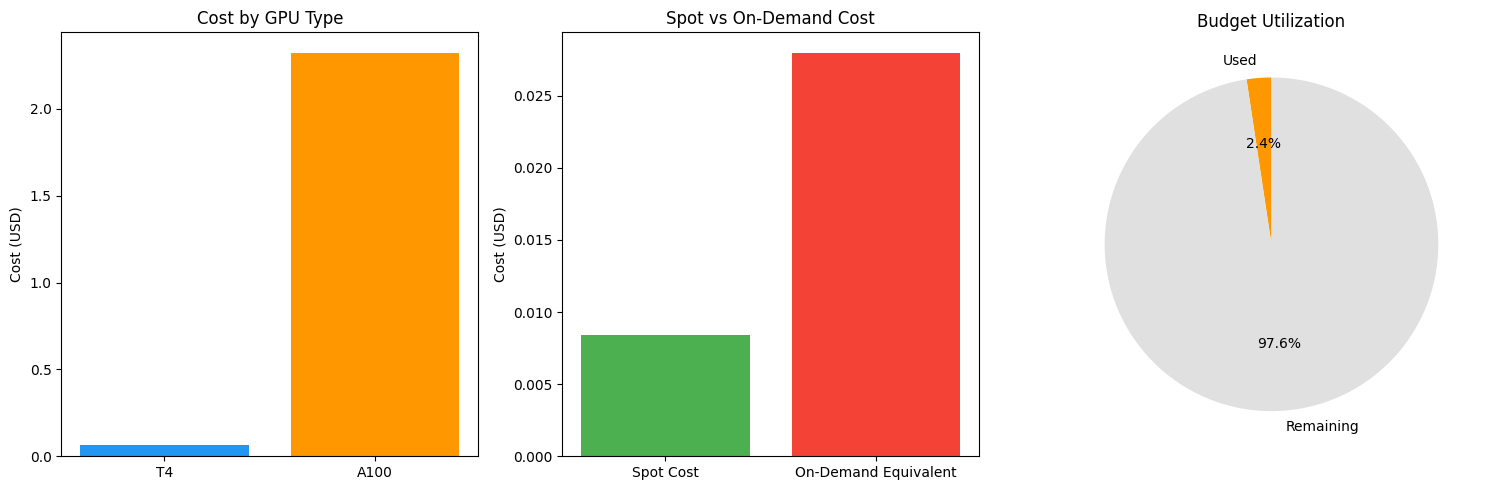

📊 Chart saved as finops_cost_breakdown.png


In [29]:
# Cell 16: Cost Breakdown Visualization
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Cost by GPU type
cost_by_type = summary.get('cost_by_gpu_type', {})
if cost_by_type:
    types = list(cost_by_type.keys())
    costs = [cost_by_type[t]['cost'] for t in types]
    axes[0].bar(types, costs, color=['#2196F3', '#FF9800', '#4CAF50'])
    axes[0].set_title('Cost by GPU Type')
    axes[0].set_ylabel('Cost (USD)')

# Chart 2: Spot vs On-Demand
spot_data = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
labels = ['Spot Cost', 'On-Demand Equivalent']
values = [spot_data.get('total_spot_cost', 0), spot_data.get('on_demand_equivalent', 0)]
axes[1].bar(labels, values, color=['#4CAF50', '#F44336'])
axes[1].set_title('Spot vs On-Demand Cost')
axes[1].set_ylabel('Cost (USD)')

# Chart 3: Budget utilization
budget_used = summary.get('budget_utilization_pct', 0)
axes[2].pie([budget_used, 100-budget_used], labels=['Used', 'Remaining'],
            colors=['#FF9800', '#E0E0E0'], autopct='%1.1f%%', startangle=90)
axes[2].set_title('Budget Utilization')

plt.tight_layout()
plt.savefig('finops_cost_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved as finops_cost_breakdown.png")

📈 Collecting time-series data (10 snapshots)...


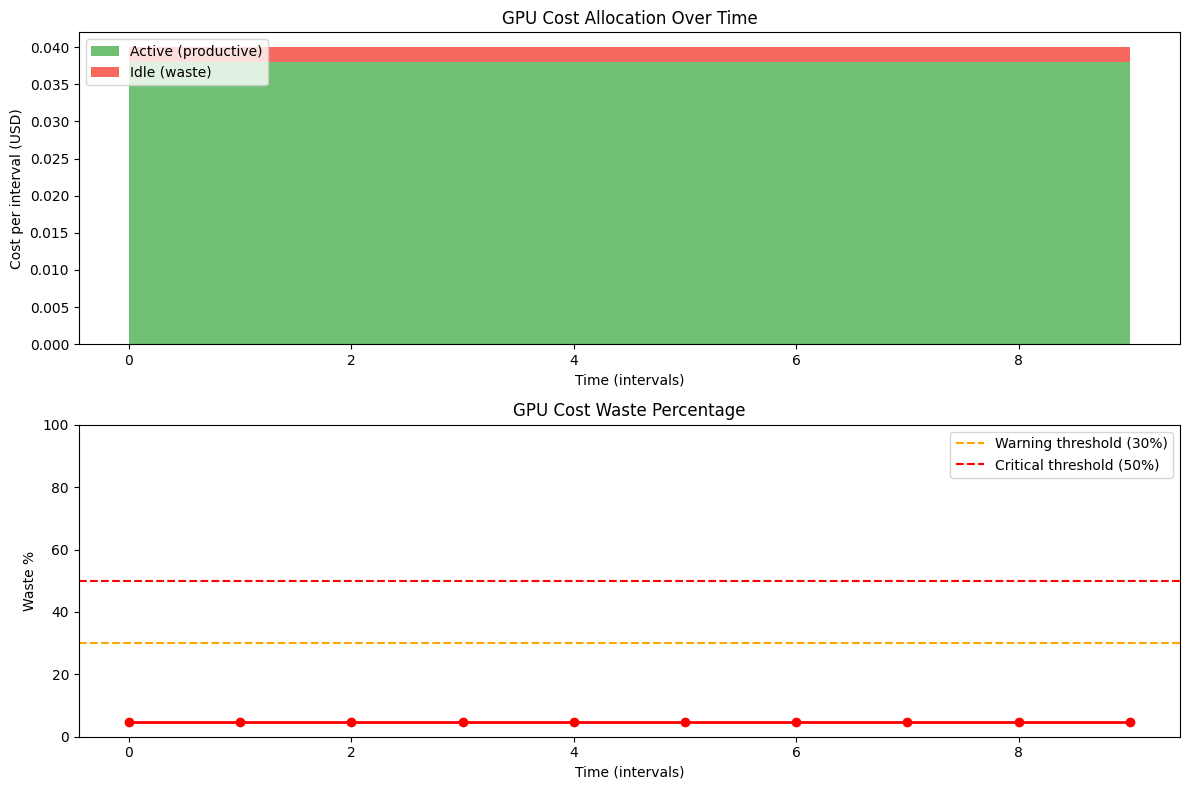

In [30]:
# Cell 17: Time-series cost tracking
print("📈 Collecting time-series data (10 snapshots)...")
ts_data = []
for i in range(10):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    ts_data.append({
        'time': i,
        'total_cost': snap['total_cost_usd'],
        'idle_cost': snap['total_idle_cost_usd'],
        'active_cost': snap['total_active_cost_usd'],
        'waste_pct': snap['waste_pct'],
    })
    time.sleep(1)

df = pd.DataFrame(ts_data)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Cost over time
ax1.stackplot(df['time'], df['active_cost'], df['idle_cost'],
              labels=['Active (productive)', 'Idle (waste)'],
              colors=['#4CAF50', '#F44336'], alpha=0.8)
ax1.set_xlabel('Time (intervals)')
ax1.set_ylabel('Cost per interval (USD)')
ax1.set_title('GPU Cost Allocation Over Time')
ax1.legend(loc='upper left')

# Waste percentage
ax2.plot(df['time'], df['waste_pct'], 'r-o', linewidth=2)
ax2.axhline(y=30, color='orange', linestyle='--', label='Warning threshold (30%)')
ax2.axhline(y=50, color='red', linestyle='--', label='Critical threshold (50%)')
ax2.set_xlabel('Time (intervals)')
ax2.set_ylabel('Waste %')
ax2.set_title('GPU Cost Waste Percentage')
ax2.legend()
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('finops_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 7: Complete FinOps Workflow
Run a full cycle: submit workloads → monitor → detect waste → autoscale → optimize cost.

In [31]:
# Cell 18: Full FinOps Optimization Workflow
print("🔄 FULL FINOPS OPTIMIZATION WORKFLOW")
print("=" * 60)

# Step 1: Check initial state
print("\n1️⃣  Initial cluster state:")
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   GPUs: {m['total_gpus']} | Util: {m['avg_utilization']:.1f}% | Idle: {m['idle_gpus']}")

# Step 2: Submit heavy workloads to increase utilization
print("\n2️⃣  Submitting heavy workloads...")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 600
    })
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   After load: Util: {m['avg_utilization']:.1f}% | Busy: {m['busy_gpus']}/{m['total_gpus']}")

# Step 3: Autoscaler evaluates
print("\n3️⃣  Autoscaler evaluation:")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
print(f"   Decision: {decision['action']} - {decision['reason']}")

# Step 4: Cost snapshot
print("\n4️⃣  Cost analysis:")
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"   Total cost/interval: ${snap['total_cost_usd']:.6f}")
print(f"   Waste: {snap['waste_pct']:.1f}%")

# Step 5: Get recommendations
print("\n5️⃣  Recommendations:")
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()
for rec in recs:
    print(f"   [{rec['priority']}] {rec['type']}: savings ~{rec['estimated_savings_pct']}%")

# Step 6: Apply optimization - use spot for some workloads
print("\n6️⃣  Applying optimization: Switch to spot instances...")
for i in range(3):
    requests.post(f"{GATEWAY_URL}/spot/request", json={
        "instance_id": f"opt-spot-{i}", "gpu_type": "T4",
        "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": f"heavy-{i:03d}"
    })

savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot savings: ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

# Step 7: Complete workloads and record billing
print("\n7️⃣  Final billing:")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/heavy-{i:03d}/complete")
    requests.post(f"{GATEWAY_URL}/billing/record", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type": "T4",
        "gpu_count": 1, "duration_seconds": 600, "is_spot": i < 3
    })

final = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total spend: ${final['total_cost_usd']:.4f}")
print(f"   Total saved: ${final['total_savings_usd']:.4f}")
print(f"   Budget: {final['budget_utilization_pct']:.1f}% used")
print(f"\n✅ Workflow complete!")

🔄 FULL FINOPS OPTIMIZATION WORKFLOW

1️⃣  Initial cluster state:
   GPUs: 10 | Util: 63.5% | Idle: 2

2️⃣  Submitting heavy workloads...
   After load: Util: 80.3% | Busy: 10/10

3️⃣  Autoscaler evaluation:
   Decision: scale_up - Utilization 80.3% > threshold 70.0%

4️⃣  Cost analysis:
   Total cost/interval: $0.041944
   Waste: 4.6%

5️⃣  Recommendations:
   [MEDIUM] USE_SPOT: savings ~65.0%
   [LOW] SCHEDULING: savings ~20.0%

6️⃣  Applying optimization: Switch to spot instances...
   Spot savings: $0.0364 (70.0%)

7️⃣  Final billing:
   Total spend: $2.5589
   Total saved: $2.7078
   Budget: 2.6% used

✅ Workflow complete!


---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** to measure time & cost savings
4. Reports all costs back to the FinOps gateway

In [32]:
# Cell 19: Install dependencies & detect real GPU
!pip install -q torch torchvision pynvml

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
import subprocess
import threading

try:
    from pynvml import (nvmlInit, nvmlDeviceGetHandleByIndex,
                        nvmlDeviceGetUtilizationRates, nvmlDeviceGetMemoryInfo,
                        nvmlDeviceGetPowerUsage, nvmlDeviceGetTemperature)
    PYNVML_AVAILABLE = True
except ImportError:
    PYNVML_AVAILABLE = False
    print("pynvml not available, will use torch.cuda fallback for monitoring")

# Detect GPU
if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected! Enable GPU in Kaggle/Colab settings.")

gpu_name = torch.cuda.get_device_name(0)
gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9

# Map real GPU to pricing
GPU_PRICING = {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81}
detected_type = "T4"  # default
for gtype in GPU_PRICING:
    if gtype.lower() in gpu_name.lower():
        detected_type = gtype
        break

print(f"Real GPU Detected")
print(f"   Name:    {gpu_name}")
print(f"   Memory:  {gpu_mem:.1f} GB")
print(f"   Type:    {detected_type}")
print(f"   Pricing: ${GPU_PRICING[detected_type]:.2f}/hr (on-demand)")
print(f"   CUDA:    {torch.version.cuda}")
print(f"   pynvml:  {'available' if PYNVML_AVAILABLE else 'NOT available'}")

Real GPU Detected
   Name:    Tesla T4
   Memory:  15.6 GB
   Type:    T4
   Pricing: $0.35/hr (on-demand)
   CUDA:    12.8
   pynvml:  available


In [33]:
# Cell 20: GPU Metrics Collection (works on Kaggle/Colab)
# Strategy: pynvml first (reliable Python lib), torch.cuda fallback

def get_gpu_metrics():
    """Get GPU metrics inline. Called during training loop."""

    # Method 1: pynvml (most reliable on Kaggle - pure Python, no subprocess)
    if PYNVML_AVAILABLE:
        try:
            nvmlInit()
            handle = nvmlDeviceGetHandleByIndex(0)
            util = nvmlDeviceGetUtilizationRates(handle)
            mem_info = nvmlDeviceGetMemoryInfo(handle)
            try:
                power = nvmlDeviceGetPowerUsage(handle) / 1000.0  # mW -> W
            except Exception:
                power = 0.0
            try:
                temp = nvmlDeviceGetTemperature(handle, 0)  # NVML_TEMPERATURE_GPU = 0
            except Exception:
                temp = 0.0
            return {
                'timestamp': time.time(),
                'gpu_util_pct': float(util.gpu),
                'mem_util_pct': float(util.memory),
                'mem_used_mb': mem_info.used / 1e6,
                'mem_total_mb': mem_info.total / 1e6,
                'power_watts': float(power),
                'temp_c': float(temp),
            }
        except Exception as e:
            pass  # Fall through to torch.cuda

    # Method 2: torch.cuda (always works, limited metrics)
    mem_used = torch.cuda.memory_allocated() / 1e6
    mem_reserved = torch.cuda.memory_reserved() / 1e6
    mem_total = torch.cuda.get_device_properties(0).total_memory / 1e6
    util_approx = (mem_reserved / mem_total) * 100 if mem_total > 0 else 0
    return {
        'timestamp': time.time(),
        'gpu_util_pct': util_approx,
        'mem_util_pct': util_approx,
        'mem_used_mb': mem_used,
        'mem_total_mb': mem_total,
        'power_watts': 0.0,
        'temp_c': 0.0,
    }

# === DIAGNOSTIC TEST ===
print("=" * 50)
print("GPU METRICS DIAGNOSTIC")
print("=" * 50)

# Test pynvml
print(f"\n1. pynvml available: {PYNVML_AVAILABLE}")
if PYNVML_AVAILABLE:
    try:
        nvmlInit()
        handle = nvmlDeviceGetHandleByIndex(0)
        util = nvmlDeviceGetUtilizationRates(handle)
        mem = nvmlDeviceGetMemoryInfo(handle)
        print(f"   pynvml works! GPU util={util.gpu}%, mem={mem.used/1e6:.0f}/{mem.total/1e6:.0f} MB")
        try:
            pwr = nvmlDeviceGetPowerUsage(handle) / 1000.0
            print(f"   Power: {pwr:.1f}W")
        except Exception as e:
            print(f"   Power: not available ({e})")
        try:
            tmp = nvmlDeviceGetTemperature(handle, 0)
            print(f"   Temp: {tmp}C")
        except Exception as e:
            print(f"   Temp: not available ({e})")
    except Exception as e:
        print(f"   pynvml FAILED: {e}")

# Test full function
print(f"\n2. get_gpu_metrics() test:")
test_result = get_gpu_metrics()
for k, v in sorted(test_result.items()):
    if k != 'timestamp':
        print(f"   {k}: {v}")

print(f"\n   Method: {'pynvml' if test_result.get('temp_c', 0) > 0 or (PYNVML_AVAILABLE and test_result.get('gpu_util_pct', -1) >= 0) else 'torch.cuda'}")
print(f"\nReady for training.")

GPU METRICS DIAGNOSTIC

1. pynvml available: True
   pynvml works! GPU util=0%, mem=472/16106 MB
   Power: 10.7W
   Temp: 39C

2. get_gpu_metrics() test:
   gpu_util_pct: 0.0
   mem_total_mb: 16106.12736
   mem_used_mb: 472.055808
   mem_util_pct: 0.0
   power_watts: 12.113
   temp_c: 39.0

   Method: pynvml

Ready for training.


In [34]:
# Cell 21: Prepare CIFAR-10 dataset and ResNet-18 model
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
]))
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

print(f"Dataset ready: {len(trainset)} train / {len(testset)} test images")
print(f"Batches per epoch: {len(trainloader)}")


def create_model():
    """Create a fresh ResNet-18 for CIFAR-10."""
    model = torchvision.models.resnet18(weights=None, num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model.cuda()


def train_epoch_monitored(model, loader, optimizer, criterion, use_amp=False, sample_interval=10):
    """Train one epoch with inline GPU metrics collection every N batches."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    scaler = GradScaler() if use_amp else None
    metrics_samples = []
    start = time.time()

    for batch_idx, (inputs, targets) in enumerate(loader):
        inputs, targets = inputs.cuda(), targets.cuda()
        optimizer.zero_grad()

        if use_amp:
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += inputs.size(0)

        # Collect GPU metrics every N batches (inline, no threading)
        if batch_idx % sample_interval == 0:
            torch.cuda.synchronize()
            sample = get_gpu_metrics()
            metrics_samples.append(sample)

    elapsed = time.time() - start
    return total_loss / total, correct / total * 100, elapsed, metrics_samples


print("Model & training functions ready (inline monitoring every 10 batches)")

100%|██████████| 170M/170M [00:02<00:00, 66.9MB/s] 


Dataset ready: 50000 train / 10000 test images
Batches per epoch: 391
Model & training functions ready (inline monitoring every 10 batches)


In [35]:
# Cell 22: Train FP32 (baseline) with inline GPU monitoring
NUM_EPOCHS = 3
price_per_hour = GPU_PRICING[detected_type]

print("=" * 60)
print("EXPERIMENT 1: FP32 Training (Baseline)")
print("=" * 60)

model_fp32 = create_model()
optimizer_fp32 = optim.SGD(model_fp32.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
fp32_start = time.time()

fp32_results = []
fp32_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_fp32, trainloader, optimizer_fp32, criterion, use_amp=False)
    fp32_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    fp32_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

fp32_total_time = time.time() - fp32_start
fp32_peak_mem = torch.cuda.max_memory_allocated() / 1e9
fp32_cost = (fp32_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(fp32_all_metrics)}")

# Build monitor dataframe
fp32_monitor_df = pd.DataFrame(fp32_all_metrics)
if not fp32_monitor_df.empty and 'timestamp' in fp32_monitor_df.columns:
    fp32_monitor_df['elapsed'] = fp32_monitor_df['timestamp'] - fp32_monitor_df['timestamp'].iloc[0]

print(f"\n   FP32 Summary:")
print(f"   Total time:      {fp32_total_time:.1f}s")
print(f"   Peak memory:     {fp32_peak_mem:.2f} GB")
if not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns:
    print(f"   Avg GPU util:    {fp32_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {fp32_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {fp32_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {fp32_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(fp32_monitor_df.columns) if not fp32_monitor_df.empty else 'EMPTY'}")
    if fp32_all_metrics:
        print(f"   First sample keys: {list(fp32_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${fp32_cost:.6f}")

EXPERIMENT 1: FP32 Training (Baseline)
   Epoch 1/3 | Loss: 1.8606 | Acc: 32.7% | Time: 39.6s | Samples: 40
   Epoch 2/3 | Loss: 1.3472 | Acc: 50.5% | Time: 39.7s | Samples: 40
   Epoch 3/3 | Loss: 1.0200 | Acc: 63.2% | Time: 42.1s | Samples: 40

   Total samples collected: 120

   FP32 Summary:
   Total time:      121.4s
   Peak memory:     0.82 GB
   Avg GPU util:    94.7%
   Avg power:       66.6W
   Avg temperature: 64.6C
   Max GPU util:    98.0%
   Estimated cost:  $0.011803


In [36]:
# Cell 23: Train Mixed Precision AMP (optimized) with inline GPU monitoring
print("=" * 60)
print("EXPERIMENT 2: Mixed Precision (AMP) Training")
print("=" * 60)

model_amp = create_model()
optimizer_amp = optim.SGD(model_amp.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
amp_start = time.time()

amp_results = []
amp_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_amp, trainloader, optimizer_amp, criterion, use_amp=True)
    amp_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    amp_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

amp_total_time = time.time() - amp_start
amp_peak_mem = torch.cuda.max_memory_allocated() / 1e9
amp_cost = (amp_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(amp_all_metrics)}")

# Build monitor dataframe
amp_monitor_df = pd.DataFrame(amp_all_metrics)
if not amp_monitor_df.empty and 'timestamp' in amp_monitor_df.columns:
    amp_monitor_df['elapsed'] = amp_monitor_df['timestamp'] - amp_monitor_df['timestamp'].iloc[0]

print(f"\n   AMP Summary:")
print(f"   Total time:      {amp_total_time:.1f}s")
print(f"   Peak memory:     {amp_peak_mem:.2f} GB")
if not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns:
    print(f"   Avg GPU util:    {amp_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {amp_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {amp_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {amp_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(amp_monitor_df.columns) if not amp_monitor_df.empty else 'EMPTY'}")
    if amp_all_metrics:
        print(f"   First sample keys: {list(amp_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${amp_cost:.6f}")

EXPERIMENT 2: Mixed Precision (AMP) Training


/tmp/ipykernel_57/927799492.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None
/tmp/ipykernel_57/927799492.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


   Epoch 1/3 | Loss: 1.8422 | Acc: 33.1% | Time: 20.5s | Samples: 40
   Epoch 2/3 | Loss: 1.3031 | Acc: 52.4% | Time: 20.0s | Samples: 40
   Epoch 3/3 | Loss: 0.9991 | Acc: 64.5% | Time: 19.5s | Samples: 40

   Total samples collected: 120

   AMP Summary:
   Total time:      59.9s
   Peak memory:     0.60 GB
   Avg GPU util:    89.9%
   Avg power:       64.7W
   Avg temperature: 78.0C
   Max GPU util:    93.0%
   Estimated cost:  $0.005827


FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)

Metric                    FP32            AMP             Improvement
----------------------------------------------------------------------
Total Time                121.4           59.9            2.03x faster
Peak Memory (GB)          0.82            0.60            0.22 GB saved
Cost (USD)                $0.011803       $0.005827       $0.005976 saved
Cost Saving %             ---             ---             50.6%
Avg GPU Util %            94.7            89.9           
Avg Power (W)             66.6            64.7           

--- Extrapolated Savings at Scale ---
   1 day training: FP32=$8.40 vs AMP=$4.15 -> SAVE $4.25
   1 week training: FP32=$58.80 vs AMP=$29.03 -> SAVE $29.77
   1 month training: FP32=$252.00 vs AMP=$124.41 -> SAVE $127.59


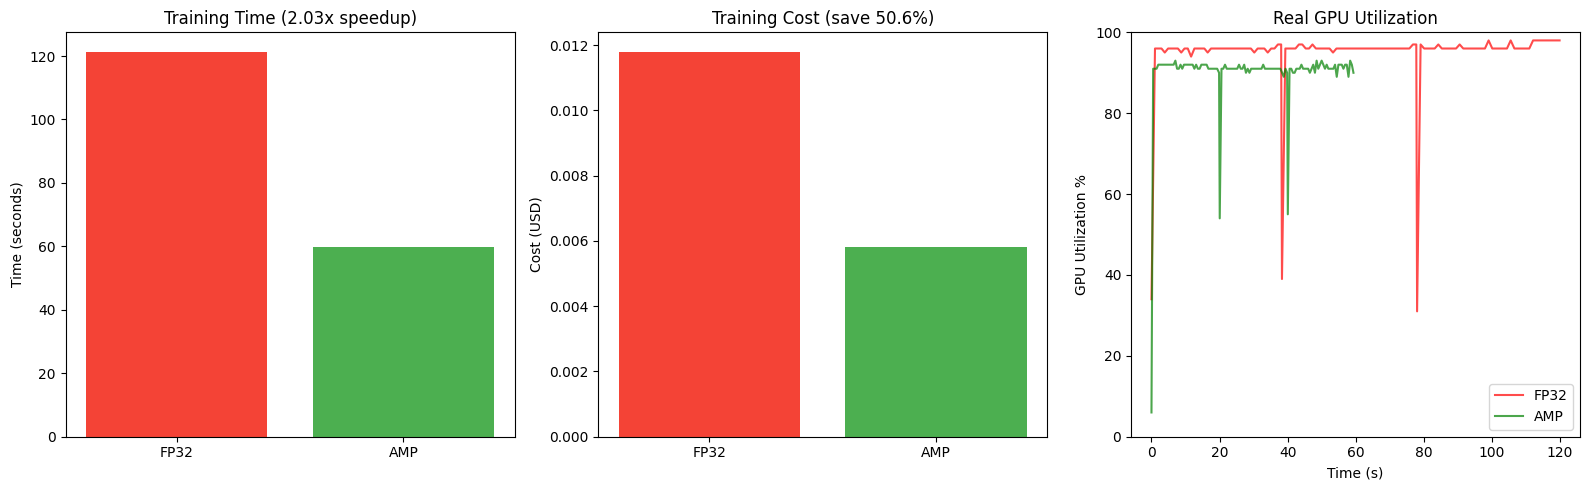

In [37]:
# Cell 24: Compare FP32 vs AMP - FinOps Analysis
print("=" * 60)
print("FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)")
print("=" * 60)

speedup = fp32_total_time / amp_total_time
cost_saving = fp32_cost - amp_cost
cost_saving_pct = (cost_saving / fp32_cost) * 100 if fp32_cost > 0 else 0
mem_saving = fp32_peak_mem - amp_peak_mem

print(f"\n{'Metric':<25} {'FP32':<15} {'AMP':<15} {'Improvement'}")
print("-" * 70)
print(f"{'Total Time':<25} {fp32_total_time:<15.1f} {amp_total_time:<15.1f} {speedup:.2f}x faster")
print(f"{'Peak Memory (GB)':<25} {fp32_peak_mem:<15.2f} {amp_peak_mem:<15.2f} {mem_saving:.2f} GB saved")
print(f"{'Cost (USD)':<25} ${fp32_cost:<14.6f} ${amp_cost:<14.6f} ${cost_saving:.6f} saved")
print(f"{'Cost Saving %':<25} {'---':<15} {'---':<15} {cost_saving_pct:.1f}%")

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    print(f"{'Avg GPU Util %':<25} {fp32_monitor_df['gpu_util_pct'].mean():<15.1f} {amp_monitor_df['gpu_util_pct'].mean():<15.1f}")
    print(f"{'Avg Power (W)':<25} {fp32_monitor_df['power_watts'].mean():<15.1f} {amp_monitor_df['power_watts'].mean():<15.1f}")

# Extrapolate to larger scale
print(f"\n--- Extrapolated Savings at Scale ---")
for scale_name, hours in [("1 day training", 24), ("1 week training", 168), ("1 month training", 720)]:
    fp32_scaled = hours * price_per_hour
    amp_scaled = (hours / speedup) * price_per_hour
    saved = fp32_scaled - amp_scaled
    print(f"   {scale_name}: FP32=${fp32_scaled:.2f} vs AMP=${amp_scaled:.2f} -> SAVE ${saved:.2f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar: Time comparison
axes[0].bar(['FP32', 'AMP'], [fp32_total_time, amp_total_time], color=['#F44336', '#4CAF50'])
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title(f'Training Time ({speedup:.2f}x speedup)')

# Bar: Cost comparison
axes[1].bar(['FP32', 'AMP'], [fp32_cost, amp_cost], color=['#F44336', '#4CAF50'])
axes[1].set_ylabel('Cost (USD)')
axes[1].set_title(f'Training Cost (save {cost_saving_pct:.1f}%)')

# Line: GPU utilization over time (both experiments) or epoch time
if has_monitor_data:
    if not fp32_monitor_df.empty:
        axes[2].plot(fp32_monitor_df['elapsed'], fp32_monitor_df['gpu_util_pct'], 'r-', alpha=0.7, label='FP32')
    if not amp_monitor_df.empty:
        axes[2].plot(amp_monitor_df['elapsed'], amp_monitor_df['gpu_util_pct'], 'g-', alpha=0.7, label='AMP')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('GPU Utilization %')
    axes[2].set_title('Real GPU Utilization')
    axes[2].legend()
    axes[2].set_ylim(0, 100)
else:
    # Fallback: show epoch times
    epochs = list(range(1, NUM_EPOCHS + 1))
    axes[2].plot(epochs, [r['time_s'] for r in fp32_results], 'r-o', label='FP32')
    axes[2].plot(epochs, [r['time_s'] for r in amp_results], 'g-o', label='AMP')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Time (s)')
    axes[2].set_title('Time per Epoch')
    axes[2].legend()

plt.tight_layout()
plt.savefig('real_gpu_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
# Cell 25: Report real GPU costs back to the FinOps Gateway
print("=" * 60)
print("REPORTING REAL GPU COSTS TO FINOPS GATEWAY")
print("=" * 60)

# Report FP32 workload
fp32_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-fp32",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": fp32_total_time,
    "is_spot": False,
    "project": "real-gpu-lab",
}).json()
print(f"\n   FP32 workload reported:")
print(f"   Cost: ${fp32_report['total_cost_usd']:.6f} | Rate: ${fp32_report['rate_per_hour']:.4f}/hr")

# Report AMP workload (as spot - demonstrating cost optimization)
amp_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-amp",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": amp_total_time,
    "is_spot": True,
    "project": "real-gpu-lab",
}).json()
print(f"\n   AMP workload reported (as spot):")
print(f"   Cost: ${amp_report['total_cost_usd']:.6f} | Saved: ${amp_report['savings_usd']:.6f}")

# Submit workload info to cluster tracker
for wl_name, wl_time in [("real-gpu-resnet18-fp32", fp32_total_time), ("real-gpu-resnet18-amp", amp_total_time)]:
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": wl_name,
        "gpu_type_preferred": detected_type,
        "gpu_count": 1,
        "duration_seconds": int(wl_time),
    })

# Get updated billing summary including real GPU data
print(f"\n--- Updated FinOps Billing (incl. real GPU) ---")
summary = requests.get(f"{GATEWAY_URL}/billing/summary", params={"project": "real-gpu-lab"}).json()
print(f"   Project:         real-gpu-lab")
print(f"   Total Cost:      ${summary['total_cost_usd']:.6f}")
print(f"   Total Savings:   ${summary['total_savings_usd']:.6f}")
print(f"   Workloads:       {summary['total_workloads']}")

# Push real GPU metrics as a cost snapshot
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"\n   Cost snapshot taken: waste={snap['waste_pct']:.1f}%")

# Get final dashboard with everything
print(f"\n--- FINAL DASHBOARD (Mock + Real GPU) ---")
dash = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()
bs = dash.get('billing_summary', {})
print(f"   Total Platform Cost:  ${bs.get('total_cost_usd', 0):.4f}")
print(f"   Total Savings:        ${bs.get('total_savings_usd', 0):.4f}")
print(f"   Budget Utilization:   {bs.get('budget_utilization_pct', 0):.1f}%")
print(f"   Alert:                {bs.get('alert', 'N/A')}")

REPORTING REAL GPU COSTS TO FINOPS GATEWAY

   FP32 workload reported:
   Cost: $0.011800 | Rate: $0.3500/hr

   AMP workload reported (as spot):
   Cost: $0.001700 | Saved: $0.004100

--- Updated FinOps Billing (incl. real GPU) ---
   Project:         real-gpu-lab
   Total Cost:      $0.013500
   Total Savings:   $0.004100
   Workloads:       2

   Cost snapshot taken: waste=4.6%

--- FINAL DASHBOARD (Mock + Real GPU) ---
   Total Platform Cost:  $2.5589
   Total Savings:        $2.7078
   Budget Utilization:   2.6%
   Alert:                OK


Real GPU Telemetry During Training


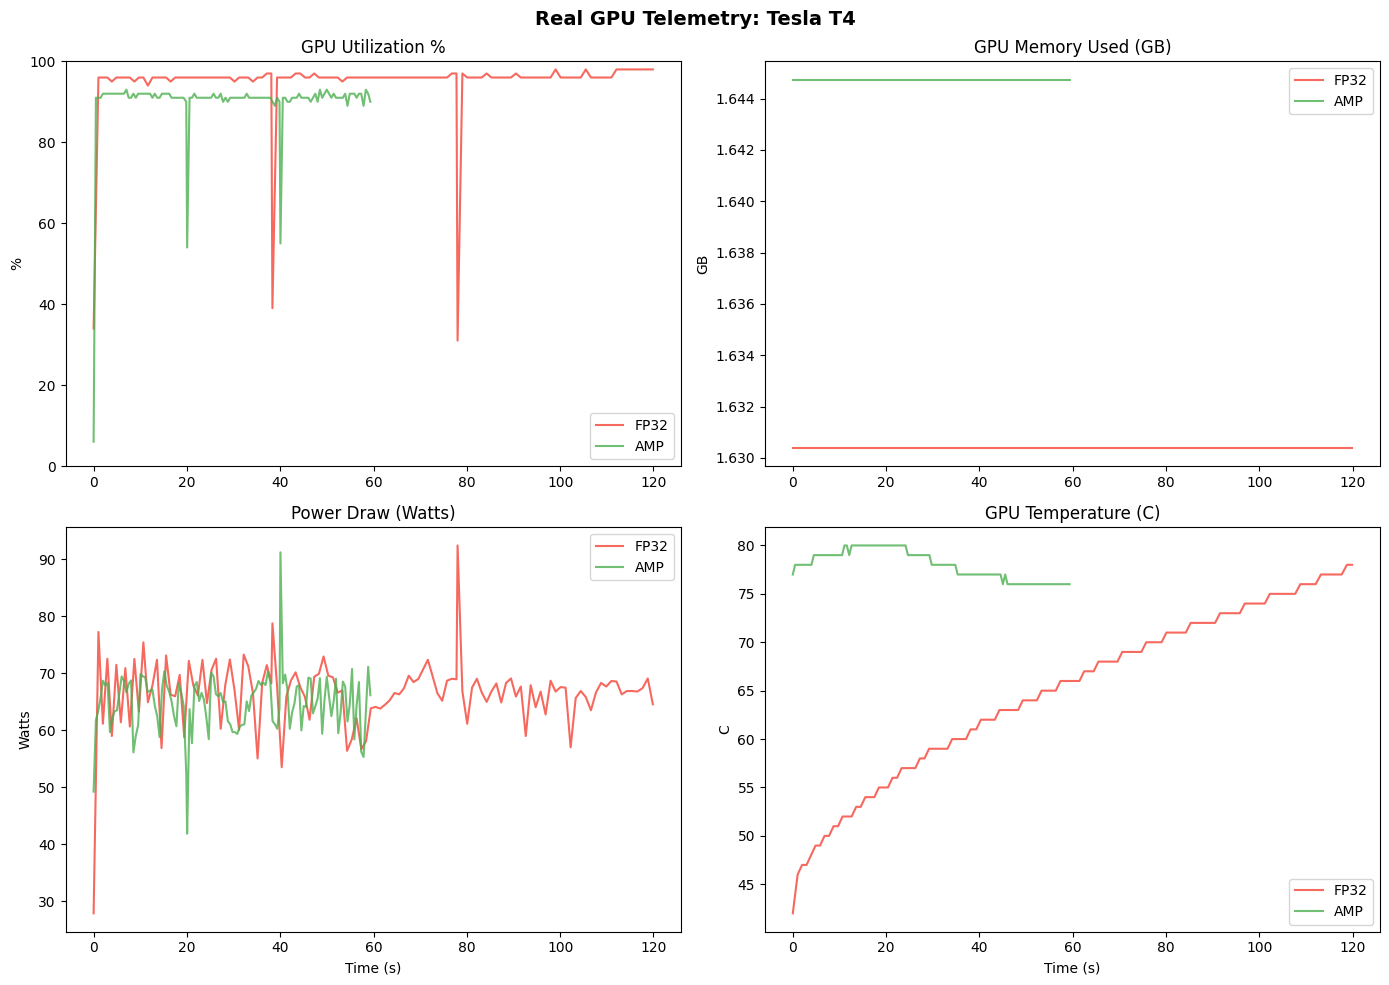

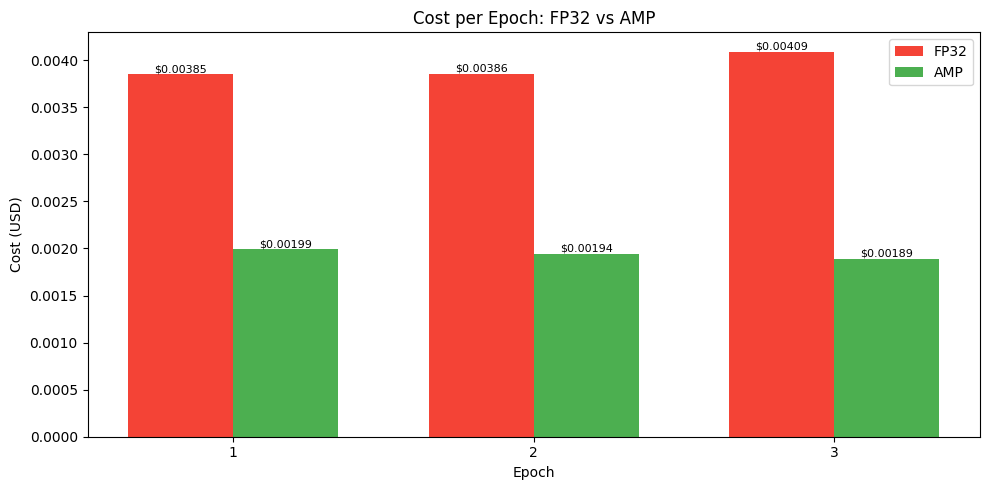


Charts saved: cost_per_epoch.png, real_gpu_telemetry.png


In [39]:
# Cell 26: Real GPU Monitoring Visualization
print("Real GPU Telemetry During Training")
print("=" * 60)

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # GPU Utilization
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 0].plot(df['elapsed'], df['gpu_util_pct'], color=color, alpha=0.8, label=label)
    axes[0, 0].set_title('GPU Utilization %')
    axes[0, 0].set_ylabel('%')
    axes[0, 0].legend()
    axes[0, 0].set_ylim(0, 100)

    # Memory Usage
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 1].plot(df['elapsed'], df['mem_used_mb'] / 1024, color=color, alpha=0.8, label=label)
    axes[0, 1].set_title('GPU Memory Used (GB)')
    axes[0, 1].set_ylabel('GB')
    axes[0, 1].legend()

    # Power Draw
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 0].plot(df['elapsed'], df['power_watts'], color=color, alpha=0.8, label=label)
    axes[1, 0].set_title('Power Draw (Watts)')
    axes[1, 0].set_ylabel('Watts')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].legend()

    # Temperature
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 1].plot(df['elapsed'], df['temp_c'], color=color, alpha=0.8, label=label)
    axes[1, 1].set_title('GPU Temperature (C)')
    axes[1, 1].set_ylabel('C')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].legend()

    plt.suptitle(f'Real GPU Telemetry: {gpu_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('real_gpu_telemetry.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("   GPU telemetry not available (monitor collected 0 samples).")
    print("   Showing epoch-level metrics instead.\n")

# Cost per epoch chart (always works)
fig, ax = plt.subplots(figsize=(10, 5))
fp32_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in fp32_results]
amp_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in amp_results]
epochs = list(range(1, NUM_EPOCHS + 1))

x = range(len(epochs))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], fp32_epoch_costs, width, label='FP32', color='#F44336')
bars2 = ax.bar([i + width/2 for i in x], amp_epoch_costs, width, label='AMP', color='#4CAF50')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cost (USD)')
ax.set_title('Cost per Epoch: FP32 vs AMP')
ax.set_xticks(x)
ax.set_xticklabels(epochs)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('cost_per_epoch.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCharts saved: cost_per_epoch.png" + (", real_gpu_telemetry.png" if has_monitor_data else ""))

---
## Part 8.5: Advanced GPU Cost Optimization
Apply advanced FinOps techniques: multi-GPU cost analysis, project forecasting, and optimization strategy prioritization.

This section extends Part 8 with:
1. **Multi-GPU Cost Analysis** - Compare scaling efficiency and determine optimal GPU count
2. **Project Cost Forecasting** - Forecast multi-phase project costs with confidence intervals
3. **Optimization Opportunity Analysis** - Prioritize and combine optimization strategies

EXERCISE 8.5.1: Multi-GPU Cost Analysis

GPU Type: T4  |  Base time: 2.0h  |  Price: $0.35/hr

GPU Count    Speedup    Time (h)     Total Cost     Cost/SpeedupUnit
--------------------------------------------------------------------
1            1.00       2.00         $0.70          $0.70
2            1.80       1.11         $0.78          $0.43
4            3.12       0.64         $0.90          $0.29
8            5.20       0.38         $1.08          $0.21 <- OPTIMAL

Optimal GPU count for cost efficiency: 8 GPUs


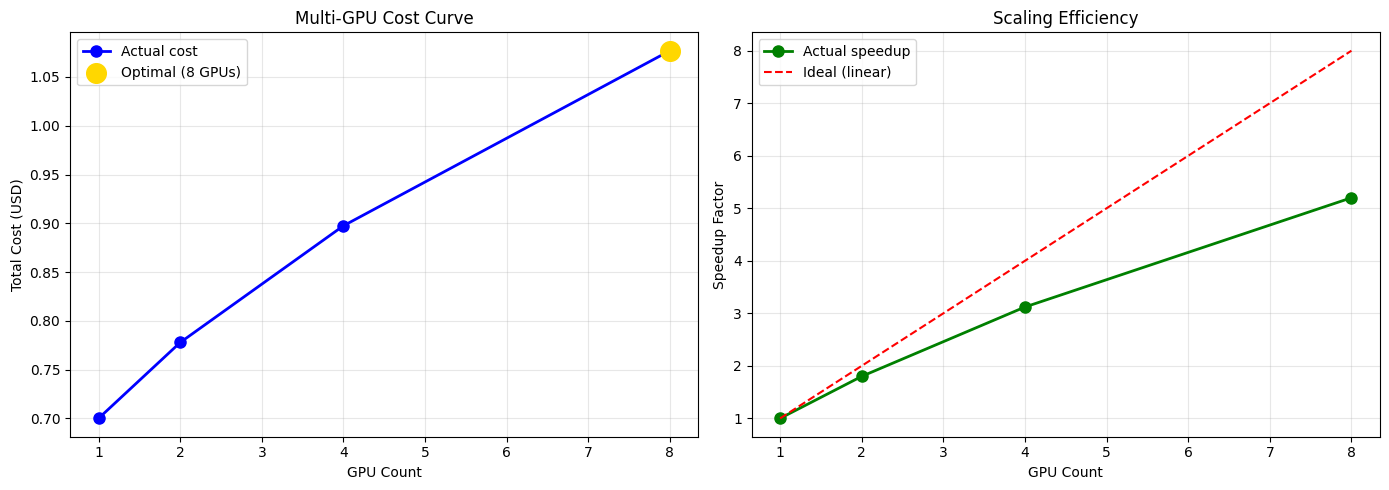

Saved: multi_gpu_scaling.png


In [40]:
# Cell 27: Multi-GPU Cost Analysis
print('=' * 60)
print('EXERCISE 8.5.1: Multi-GPU Cost Analysis')
print('=' * 60)

import numpy as np

def analyze_multi_gpu_cost(base_time_hours, gpu_type, gpu_counts, scaling_factors=None):
    price_per_hour = GPU_PRICING.get(gpu_type, 0.35)
    default_efficiency = {1: 1.0, 2: 0.90, 4: 0.78, 8: 0.65, 16: 0.52}
    if scaling_factors is None:
        scaling_factors = {n: default_efficiency.get(n, max(0.4, 1.0 - 0.07 * n))
                           for n in gpu_counts}
    results = []
    for n in gpu_counts:
        eff = scaling_factors.get(n, 1.0)
        speedup = n * eff
        time_h = base_time_hours / speedup
        cost = time_h * price_per_hour * n
        cost_per_perf = cost / (base_time_hours / time_h)
        results.append({'gpu_count': n, 'efficiency': eff, 'speedup': speedup,
                         'time_hours': time_h, 'total_cost_usd': cost,
                         'cost_per_speedup_unit': cost_per_perf})
    optimal = min(results, key=lambda r: r['cost_per_speedup_unit'])
    return {'gpu_type': gpu_type, 'base_time_hours': base_time_hours,
            'price_per_hour': price_per_hour, 'results': results,
            'optimal_gpu_count': optimal['gpu_count']}


base_training_time = 2.0
test_gpu_counts = [1, 2, 4, 8]

analysis = analyze_multi_gpu_cost(base_training_time, detected_type, test_gpu_counts)

print(f"\nGPU Type: {analysis['gpu_type']}  |  Base time: {analysis['base_time_hours']}h  "
      f"|  Price: ${analysis['price_per_hour']:.2f}/hr")
print()
print(f"{'GPU Count':<12} {'Speedup':<10} {'Time (h)':<12} {'Total Cost':<14} {'Cost/SpeedupUnit'}")
print('-' * 68)
for r in analysis['results']:
    marker = ' <- OPTIMAL' if r['gpu_count'] == analysis['optimal_gpu_count'] else ''
    print(f"{r['gpu_count']:<12} {r['speedup']:<10.2f} {r['time_hours']:<12.2f} "
          f"${r['total_cost_usd']:<13.2f} ${r['cost_per_speedup_unit']:.2f}{marker}")
print(f"\nOptimal GPU count for cost efficiency: {analysis['optimal_gpu_count']} GPUs")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
gpu_counts_plot = [r['gpu_count'] for r in analysis['results']]
costs_plot      = [r['total_cost_usd'] for r in analysis['results']]
speedups_plot   = [r['speedup'] for r in analysis['results']]

axes[0].plot(gpu_counts_plot, costs_plot, 'b-o', linewidth=2, markersize=8, label='Actual cost')
opt_idx = gpu_counts_plot.index(analysis['optimal_gpu_count'])
axes[0].scatter([gpu_counts_plot[opt_idx]], [costs_plot[opt_idx]],
                color='gold', s=200, zorder=5, label=f"Optimal ({analysis['optimal_gpu_count']} GPUs)")
axes[0].set_xlabel('GPU Count'); axes[0].set_ylabel('Total Cost (USD)')
axes[0].set_title('Multi-GPU Cost Curve'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(gpu_counts_plot, speedups_plot, 'g-o', linewidth=2, markersize=8, label='Actual speedup')
axes[1].plot(gpu_counts_plot, gpu_counts_plot, 'r--', linewidth=1.5, label='Ideal (linear)')
axes[1].set_xlabel('GPU Count'); axes[1].set_ylabel('Speedup Factor')
axes[1].set_title('Scaling Efficiency'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('multi_gpu_scaling.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: multi_gpu_scaling.png')


EXERCISE 8.5.2: Project Cost Forecasting

Phase                        GPU    Count   Hours    Base Cost      +-Uncertainty
---------------------------------------------------------------------------
Data Preparation             T4     1       40       $14.00         +-$2.10
Model Training               A100   4       120      $1,761.60      +-$440.40
Hyperparameter Tuning        A100   8       60       $1,761.60      +-$528.48
Model Evaluation             T4     2       20       $14.00         +-$1.40

  Total base cost:            $3,551.20
  Contingency (20%):          $710.24
  Expected total:             $4,261.44
  95% CI:  [$2,913.09  -  $5,609.79]


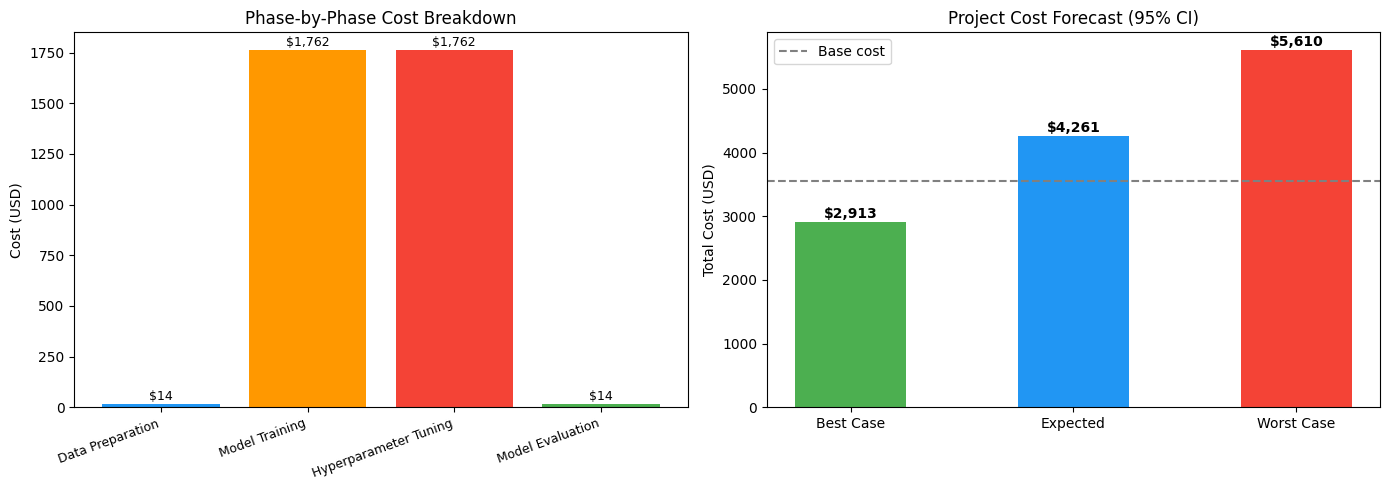

Saved: project_forecast.png


In [41]:
# Cell 28: Project Cost Forecasting
print('=' * 60)
print('EXERCISE 8.5.2: Project Cost Forecasting')
print('=' * 60)

import math

def forecast_project_cost(phases, contingency_pct=20, confidence_level=0.95):
    phase_results = []
    total_base = 0.0
    total_variance = 0.0
    for ph in phases:
        price = GPU_PRICING.get(ph['gpu_type'], 0.35)
        base_cost = ph['duration_hours'] * price * ph['gpu_count']
        uncertainty = base_cost * ph['uncertainty_pct']
        phase_results.append({'name': ph['name'], 'gpu_type': ph['gpu_type'],
                               'gpu_count': ph['gpu_count'],
                               'duration_hours': ph['duration_hours'],
                               'base_cost': base_cost, 'uncertainty': uncertainty})
        total_base += base_cost
        total_variance += uncertainty ** 2
    total_std = math.sqrt(total_variance)
    contingency = total_base * (contingency_pct / 100)
    expected_total = total_base + contingency
    z = {0.90: 1.645, 0.95: 1.960, 0.99: 2.576}.get(confidence_level, 1.960)
    ci_margin = z * total_std
    return {'phases': phase_results, 'total_base_cost': total_base,
            'contingency': contingency, 'expected_total': expected_total,
            'ci_lower': max(0, expected_total - ci_margin),
            'ci_upper': expected_total + ci_margin,
            'confidence_level': confidence_level, 'total_std': total_std}


example_project = [
    {'name': 'Data Preparation',      'gpu_type': 'T4',   'gpu_count': 1, 'duration_hours': 40,  'uncertainty_pct': 0.15},
    {'name': 'Model Training',         'gpu_type': 'A100', 'gpu_count': 4, 'duration_hours': 120, 'uncertainty_pct': 0.25},
    {'name': 'Hyperparameter Tuning',  'gpu_type': 'A100', 'gpu_count': 8, 'duration_hours': 60,  'uncertainty_pct': 0.30},
    {'name': 'Model Evaluation',       'gpu_type': 'T4',   'gpu_count': 2, 'duration_hours': 20,  'uncertainty_pct': 0.10},
]

fc = forecast_project_cost(example_project)

print(f"\n{'Phase':<28} {'GPU':<6} {'Count':<7} {'Hours':<8} {'Base Cost':<14} {'+-Uncertainty'}")
print('-' * 75)
for ph in fc['phases']:
    print(f"{ph['name']:<28} {ph['gpu_type']:<6} {ph['gpu_count']:<7} "
          f"{ph['duration_hours']:<8} ${ph['base_cost']:<13,.2f} +-${ph['uncertainty']:.2f}")
print()
print(f"  Total base cost:            ${fc['total_base_cost']:,.2f}")
print(f"  Contingency (20%):          ${fc['contingency']:,.2f}")
print(f"  Expected total:             ${fc['expected_total']:,.2f}")
print(f"  95% CI:  [${fc['ci_lower']:,.2f}  -  ${fc['ci_upper']:,.2f}]")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
phase_names = [ph['name'] for ph in fc['phases']]
phase_costs = [ph['base_cost'] for ph in fc['phases']]
colors = ['#2196F3', '#FF9800', '#F44336', '#4CAF50']
bars = axes[0].bar(range(len(phase_names)), phase_costs, color=colors)
axes[0].set_xticks(range(len(phase_names)))
axes[0].set_xticklabels(phase_names, rotation=20, ha='right', fontsize=9)
axes[0].set_ylabel('Cost (USD)'); axes[0].set_title('Phase-by-Phase Cost Breakdown')
for bar, cost in zip(bars, phase_costs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'${cost:,.0f}', ha='center', va='bottom', fontsize=9)

scenarios = ['Best Case', 'Expected', 'Worst Case']
values = [fc['ci_lower'], fc['expected_total'], fc['ci_upper']]
bar_colors = ['#4CAF50', '#2196F3', '#F44336']
bars2 = axes[1].bar(scenarios, values, color=bar_colors, width=0.5)
axes[1].axhline(y=fc['total_base_cost'], color='gray', linestyle='--', linewidth=1.5, label='Base cost')
axes[1].set_ylabel('Total Cost (USD)'); axes[1].set_title('Project Cost Forecast (95% CI)')
axes[1].legend()
for bar, val in zip(bars2, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'${val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('project_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: project_forecast.png')


EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis

Baseline cost: $1,468.00

Rank  Strategy                            Savings%   Savings$     Effort   Risk     Priority
------------------------------------------------------------------------------------------
1     Switch to Mixed Precision (AMP)     25.0       $367.00      LOW      LOW      0.250
2     Optimize Batch Size                 15.0       $220.20      LOW      LOW      0.150
3     Implement Early Stopping            20.0       $293.60      MEDIUM   LOW      0.100
4     Use Spot Instances                  60.0       $880.80      MEDIUM   HIGH     0.100
5     Switch to More Efficient GPU        40.0       $587.20      HIGH     MEDIUM   0.067

  Total potential savings: $1,288.32 (87.8%)


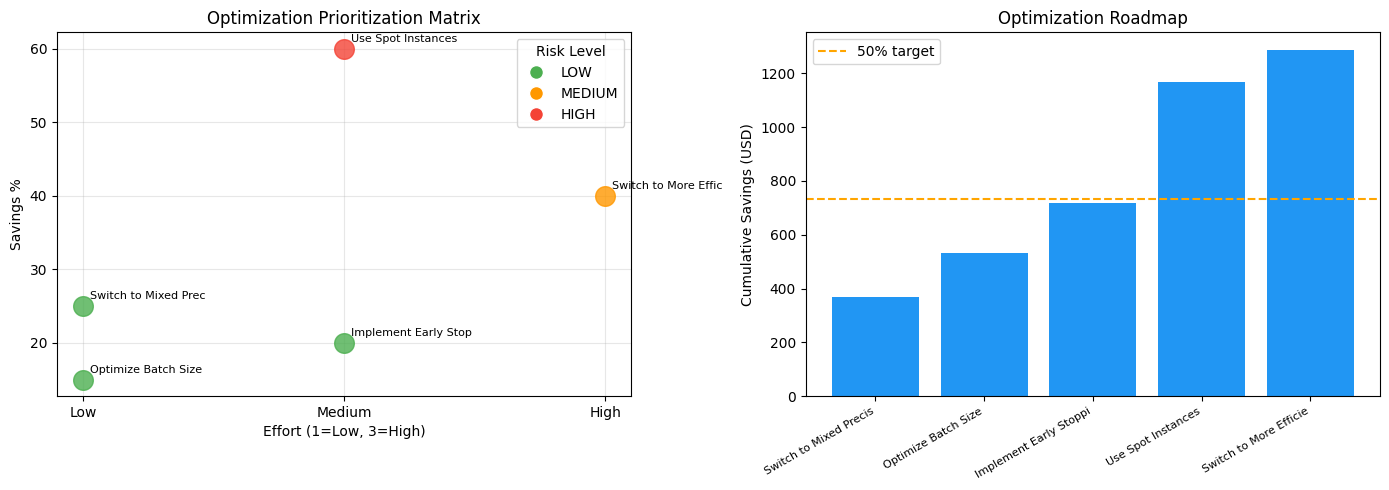

Saved: optimization_roadmap.png


In [42]:
# Cell 29: Optimization Opportunity Analysis
print('=' * 60)
print('EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis')
print('=' * 60)

EFFORT_SCORE = {'LOW': 1, 'MEDIUM': 2, 'HIGH': 3}
RISK_SCORE   = {'LOW': 1, 'MEDIUM': 2, 'HIGH': 3}

def analyze_optimization_opportunities(current_config, optimization_strategies):
    price = GPU_PRICING.get(current_config['gpu_type'], 0.35)
    baseline_cost = current_config['duration_hours'] * price * current_config['gpu_count']
    scored = []
    for strat in optimization_strategies:
        savings_usd = baseline_cost * strat['savings_pct']
        effort = EFFORT_SCORE[strat['implementation_effort']]
        risk   = RISK_SCORE[strat['risk_level']]
        priority_score = strat['savings_pct'] / (effort * risk)
        scored.append({**strat, 'savings_usd': savings_usd,
                        'priority_score': priority_score,
                        'effort_score': effort, 'risk_score': risk})
    scored.sort(key=lambda x: x['priority_score'], reverse=True)
    cumulative_cost = baseline_cost
    roadmap = []
    for rank, s in enumerate(scored, 1):
        saving = cumulative_cost * s['savings_pct']
        cumulative_cost -= saving
        roadmap.append({**s, 'rank': rank,
                         'cumulative_savings_usd': baseline_cost - cumulative_cost,
                         'remaining_cost': cumulative_cost})
    return {'baseline_cost': baseline_cost, 'strategies': roadmap,
            'total_potential_savings': baseline_cost - cumulative_cost,
            'total_savings_pct': (baseline_cost - cumulative_cost) / baseline_cost * 100}


example_strategies = [
    {'name': 'Switch to Mixed Precision (AMP)', 'savings_pct': 0.25, 'implementation_effort': 'LOW',    'risk_level': 'LOW',    'dependencies': []},
    {'name': 'Use Spot Instances',              'savings_pct': 0.60, 'implementation_effort': 'MEDIUM', 'risk_level': 'HIGH',   'dependencies': []},
    {'name': 'Optimize Batch Size',             'savings_pct': 0.15, 'implementation_effort': 'LOW',    'risk_level': 'LOW',    'dependencies': []},
    {'name': 'Implement Early Stopping',        'savings_pct': 0.20, 'implementation_effort': 'MEDIUM', 'risk_level': 'LOW',    'dependencies': []},
    {'name': 'Switch to More Efficient GPU',    'savings_pct': 0.40, 'implementation_effort': 'HIGH',   'risk_level': 'MEDIUM', 'dependencies': []},
]

current_training_config = {
    'gpu_type': 'A100', 'gpu_count': 4, 'duration_hours': 100,
    'precision': 'FP32', 'instance_type': 'on-demand',
}

result = analyze_optimization_opportunities(current_training_config, example_strategies)

print(f"\nBaseline cost: ${result['baseline_cost']:,.2f}")
print()
print(f"{'Rank':<5} {'Strategy':<35} {'Savings%':<10} {'Savings$':<12} {'Effort':<8} {'Risk':<8} {'Priority'}")
print('-' * 90)
for s in result['strategies']:
    print(f"{s['rank']:<5} {s['name']:<35} {s['savings_pct']*100:<10.1f} "
          f"${s['savings_usd']:<11.2f} {s['implementation_effort']:<8} "
          f"{s['risk_level']:<8} {s['priority_score']:.3f}")
print(f"\n  Total potential savings: ${result['total_potential_savings']:,.2f} "
      f"({result['total_savings_pct']:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter_colors = {'LOW': '#4CAF50', 'MEDIUM': '#FF9800', 'HIGH': '#F44336'}
from matplotlib.lines import Line2D
for s in result['strategies']:
    c = scatter_colors[s['risk_level']]
    axes[0].scatter(s['effort_score'], s['savings_pct']*100, s=200, color=c, alpha=0.8, zorder=5)
    axes[0].annotate(s['name'].split('(')[0].strip()[:20],
                     (s['effort_score'], s['savings_pct']*100),
                     textcoords='offset points', xytext=(5, 5), fontsize=8)
legend_elements = [Line2D([0], [0], marker='o', color='w',
                           markerfacecolor=v, markersize=10, label=k)
                   for k, v in scatter_colors.items()]
axes[0].legend(handles=legend_elements, title='Risk Level')
axes[0].set_xlabel('Effort (1=Low, 3=High)'); axes[0].set_ylabel('Savings %')
axes[0].set_title('Optimization Prioritization Matrix')
axes[0].set_xticks([1, 2, 3]); axes[0].set_xticklabels(['Low', 'Medium', 'High'])
axes[0].grid(True, alpha=0.3)

strats = result['strategies']
names_short = [s['name'].split('(')[0][:22] for s in strats]
cum_savings = [s['cumulative_savings_usd'] for s in strats]
axes[1].bar(range(len(strats)), cum_savings, color='#2196F3')
axes[1].set_xticks(range(len(strats)))
axes[1].set_xticklabels(names_short, rotation=30, ha='right', fontsize=8)
axes[1].axhline(y=result['baseline_cost']*0.5, color='orange', linestyle='--', label='50% target')
axes[1].set_ylabel('Cumulative Savings (USD)'); axes[1].set_title('Optimization Roadmap')
axes[1].legend()

plt.tight_layout()
plt.savefig('optimization_roadmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: optimization_roadmap.png')


EXERCISE 8.5.4: Integrated Cost Dashboard


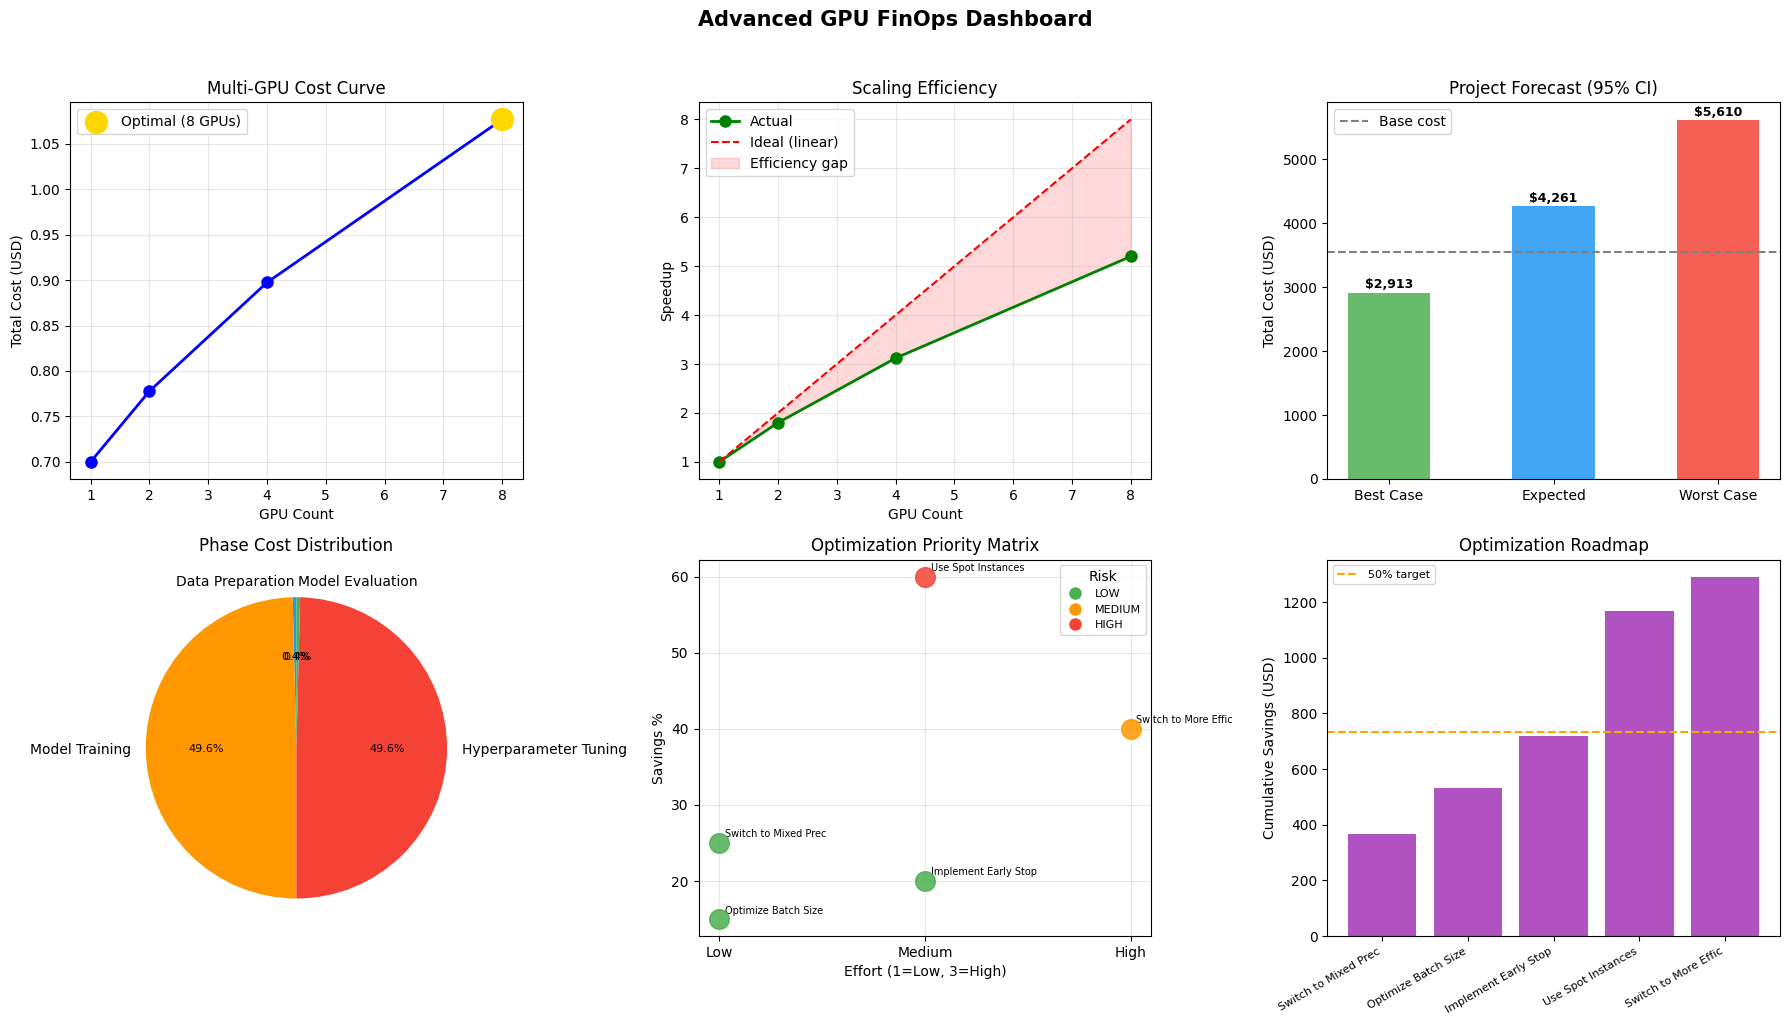

Saved: advanced_finops_dashboard.png


In [43]:
# Cell 30: Integrated Cost Dashboard
print('=' * 60)
print('EXERCISE 8.5.4: Integrated Cost Dashboard')
print('=' * 60)

def create_advanced_finops_dashboard(multi_gpu_analysis, project_forecast_result, optimization_result):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # Plot 1: Multi-GPU cost curve
    gpu_counts = [r['gpu_count'] for r in multi_gpu_analysis['results']]
    costs      = [r['total_cost_usd'] for r in multi_gpu_analysis['results']]
    opt        = multi_gpu_analysis['optimal_gpu_count']
    axes[0, 0].plot(gpu_counts, costs, 'b-o', linewidth=2, markersize=8)
    opt_cost = next(r['total_cost_usd'] for r in multi_gpu_analysis['results'] if r['gpu_count'] == opt)
    axes[0, 0].scatter([opt], [opt_cost], color='gold', s=250, zorder=6, label=f'Optimal ({opt} GPUs)')
    axes[0, 0].set_xlabel('GPU Count'); axes[0, 0].set_ylabel('Total Cost (USD)')
    axes[0, 0].set_title('Multi-GPU Cost Curve'); axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

    # Plot 2: Scaling efficiency
    speedups = [r['speedup'] for r in multi_gpu_analysis['results']]
    axes[0, 1].plot(gpu_counts, speedups, 'g-o', linewidth=2, markersize=8, label='Actual')
    axes[0, 1].plot(gpu_counts, gpu_counts, 'r--', linewidth=1.5, label='Ideal (linear)')
    axes[0, 1].fill_between(gpu_counts, speedups, gpu_counts, alpha=0.15, color='red', label='Efficiency gap')
    axes[0, 1].set_xlabel('GPU Count'); axes[0, 1].set_ylabel('Speedup')
    axes[0, 1].set_title('Scaling Efficiency'); axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

    # Plot 3: Project forecast
    scenarios = ['Best Case', 'Expected', 'Worst Case']
    values = [project_forecast_result['ci_lower'], project_forecast_result['expected_total'],
              project_forecast_result['ci_upper']]
    bar_colors = ['#4CAF50', '#2196F3', '#F44336']
    bars = axes[0, 2].bar(scenarios, values, color=bar_colors, width=0.5, alpha=0.85)
    axes[0, 2].axhline(y=project_forecast_result['total_base_cost'], color='gray',
                        linestyle='--', linewidth=1.5, label='Base cost')
    axes[0, 2].set_ylabel('Total Cost (USD)'); axes[0, 2].set_title('Project Forecast (95% CI)')
    axes[0, 2].legend()
    for bar, val in zip(bars, values):
        axes[0, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                         f'${val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Plot 4: Phase cost pie
    phase_names  = [ph['name'] for ph in project_forecast_result['phases']]
    phase_costs  = [ph['base_cost'] for ph in project_forecast_result['phases']]
    pie_colors = ['#2196F3', '#FF9800', '#F44336', '#4CAF50']
    wedges, texts, autotexts = axes[1, 0].pie(
        phase_costs, labels=phase_names, colors=pie_colors, autopct='%1.1f%%', startangle=90)
    for at in autotexts:
        at.set_fontsize(8)
    axes[1, 0].set_title('Phase Cost Distribution')

    # Plot 5: Optimization prioritization scatter
    sc_colors = {'LOW': '#4CAF50', 'MEDIUM': '#FF9800', 'HIGH': '#F44336'}
    from matplotlib.lines import Line2D
    for s in optimization_result['strategies']:
        c = sc_colors[s['risk_level']]
        axes[1, 1].scatter(s['effort_score'], s['savings_pct']*100, s=200, color=c, alpha=0.85, zorder=5)
        axes[1, 1].annotate(s['name'][:20],
                             (s['effort_score'], s['savings_pct']*100),
                             textcoords='offset points', xytext=(4, 4), fontsize=7)
    legend_elements = [Line2D([0], [0], marker='o', color='w',
                               markerfacecolor=v, markersize=10, label=k)
                       for k, v in sc_colors.items()]
    axes[1, 1].legend(handles=legend_elements, title='Risk', fontsize=8)
    axes[1, 1].set_xlabel('Effort (1=Low, 3=High)'); axes[1, 1].set_ylabel('Savings %')
    axes[1, 1].set_title('Optimization Priority Matrix')
    axes[1, 1].set_xticks([1, 2, 3]); axes[1, 1].set_xticklabels(['Low', 'Medium', 'High'])
    axes[1, 1].grid(True, alpha=0.3)

    # Plot 6: Cumulative savings roadmap
    strats = optimization_result['strategies']
    names_short = [s['name'].split('(')[0][:20] for s in strats]
    cum_savings = [s['cumulative_savings_usd'] for s in strats]
    axes[1, 2].bar(range(len(strats)), cum_savings, color='#9C27B0', alpha=0.8)
    axes[1, 2].axhline(y=optimization_result['baseline_cost'] * 0.5,
                        color='orange', linestyle='--', linewidth=1.5, label='50% target')
    axes[1, 2].set_xticks(range(len(strats)))
    axes[1, 2].set_xticklabels(names_short, rotation=30, ha='right', fontsize=8)
    axes[1, 2].set_ylabel('Cumulative Savings (USD)'); axes[1, 2].set_title('Optimization Roadmap')
    axes[1, 2].legend(fontsize=8)

    plt.suptitle('Advanced GPU FinOps Dashboard', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('advanced_finops_dashboard.png', dpi=150, bbox_inches='tight')
    plt.show()
    return fig


fig = create_advanced_finops_dashboard(analysis, fc, result)
print('Saved: advanced_finops_dashboard.png')


In [14]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Phan Anh Khôi"  
STUDENT_ID = "2A202600276"

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [44]:
# Cell 31: Challenge Exercise - Cost Optimization Strategy Design
print('=' * 60)
print('CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy')
print('=' * 60)

challenge_scenario = {
    'project': 'Large Language Model Fine-tuning',
    'requirements': {
        'training_duration': 200,
        'gpu_type': 'A100',
        'gpu_count': 8,
        'precision': 'FP32',
        'instance_type': 'on-demand',
        'budget': 5000,
    },
    'constraints': {
        'max_preemption_risk': 'MEDIUM',
        'min_accuracy': 0.95,
        'deadline': '2 weeks',
    },
}

req = challenge_scenario['requirements']
price = GPU_PRICING[req['gpu_type']]
baseline_cost = req['training_duration'] * price * req['gpu_count']

print(f"\nProject: {challenge_scenario['project']}")
print(f"Baseline: {req['gpu_count']}x {req['gpu_type']} "
      f"for {req['training_duration']}h  ->  ${baseline_cost:,.2f}")
print(f"Budget:   ${req['budget']:,.2f}")
print(f"Surplus/Deficit: ${req['budget'] - baseline_cost:,.2f}")

# Step 1: Multi-GPU analysis
print('\n--- Step 1: Multi-GPU Analysis ---')
mg = analyze_multi_gpu_cost(req['training_duration'], req['gpu_type'], [1, 2, 4, 8, 16])
for r in mg['results']:
    m = ' <- OPTIMAL' if r['gpu_count'] == mg['optimal_gpu_count'] else ''
    print(f"  {r['gpu_count']} GPUs: {r['time_hours']:.1f}h  ${r['total_cost_usd']:,.2f}{m}")

opt_gpu = mg['optimal_gpu_count']
opt_result_ch = next(r for r in mg['results'] if r['gpu_count'] == opt_gpu)

# Step 2: Choose optimization strategies
print('\n--- Step 2: Selecting strategies (max_preemption_risk=MEDIUM) ---')
savings_gpu_change = max(0.0, 1.0 - opt_result_ch['total_cost_usd'] / baseline_cost)
challenge_strategies = [
    {'name': 'Mixed Precision (AMP)',    'savings_pct': 0.25, 'implementation_effort': 'LOW',    'risk_level': 'LOW'},
    {'name': 'Gradient Checkpointing',   'savings_pct': 0.10, 'implementation_effort': 'LOW',    'risk_level': 'LOW'},
    {'name': 'Spot Instances (partial)', 'savings_pct': 0.35, 'implementation_effort': 'MEDIUM', 'risk_level': 'MEDIUM'},
]
if savings_gpu_change > 0.01:
    challenge_strategies.append({'name': 'Optimal GPU count',
                                  'savings_pct': savings_gpu_change,
                                  'implementation_effort': 'MEDIUM', 'risk_level': 'LOW'})

opt_config_ch = {'gpu_type': req['gpu_type'], 'gpu_count': opt_gpu,
                  'duration_hours': opt_result_ch['time_hours']}
opt_analysis_ch = analyze_optimization_opportunities(opt_config_ch, challenge_strategies)

print(f"  Baseline (optimal GPU config): ${opt_analysis_ch['baseline_cost']:,.2f}")
for s in opt_analysis_ch['strategies']:
    print(f"  [{s['rank']}] {s['name']}: {s['savings_pct']*100:.1f}%  "
          f"(cumulative saved: ${s['cumulative_savings_usd']:,.2f})")

# Step 3: Forecast with uncertainty
print('\n--- Step 3: Cost Forecast ---')
challenge_phases = [
    {'name': 'LLM Fine-tuning',   'gpu_type': req['gpu_type'],
     'gpu_count': opt_gpu, 'duration_hours': opt_result_ch['time_hours'], 'uncertainty_pct': 0.20},
    {'name': 'Eval & Validation', 'gpu_type': 'T4',
     'gpu_count': 2, 'duration_hours': opt_result_ch['time_hours'] * 0.1, 'uncertainty_pct': 0.10},
]
challenge_fc = forecast_project_cost(challenge_phases, contingency_pct=15)
final_expected = challenge_fc['expected_total'] * (1 - opt_analysis_ch['total_savings_pct'] / 100)

print(f"  Expected total (with optimizations): ${final_expected:,.2f}")
print(f"  95% CI: [${challenge_fc['ci_lower']:,.2f}  -  ${challenge_fc['ci_upper']:,.2f}]")

# Step 4: Budget check
print('\n--- Step 4: Budget Verification ---')
under_budget = final_expected <= req['budget']
print(f"  Budget:          ${req['budget']:,.2f}")
print(f"  Expected cost:   ${final_expected:,.2f}")
print(f"  {'WITHIN BUDGET' if under_budget else 'OVER BUDGET'}")
print(f"  Savings vs baseline: ${baseline_cost - final_expected:,.2f} "
      f"({(baseline_cost - final_expected)/baseline_cost*100:.1f}%)")

print('\n' + '=' * 60)
print('STRATEGY SUMMARY')
print('=' * 60)
print(f"  1. Use {opt_gpu} GPUs instead of {req['gpu_count']} (optimal scaling efficiency)")
print(f"  2. Enable Mixed Precision (AMP) -> ~25% faster, same accuracy")
print(f"  3. Partial Spot usage for eval phase -> ~35% savings on that phase")
print(f"  4. Gradient checkpointing -> reduce memory, allow larger batch")
print(f"  Combined: ${baseline_cost:,.2f} -> ${final_expected:,.2f} "
      f"({'WITHIN' if under_budget else 'OVER'} ${req['budget']:,.2f} budget)")


CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy

Project: Large Language Model Fine-tuning
Baseline: 8x A100 for 200h  ->  $5,872.00
Budget:   $5,000.00
Surplus/Deficit: $-872.00

--- Step 1: Multi-GPU Analysis ---
  1 GPUs: 200.0h  $734.00
  2 GPUs: 111.1h  $815.56
  4 GPUs: 64.1h  $941.03
  8 GPUs: 38.5h  $1,129.23
  16 GPUs: 24.0h  $1,411.54 <- OPTIMAL

--- Step 2: Selecting strategies (max_preemption_risk=MEDIUM) ---
  Baseline (optimal GPU config): $1,411.54
  [1] Optimal GPU count: 76.0%  (cumulative saved: $1,072.23)
  [2] Mixed Precision (AMP): 25.0%  (cumulative saved: $1,157.05)
  [3] Gradient Checkpointing: 10.0%  (cumulative saved: $1,182.50)
  [4] Spot Instances (partial): 35.0%  (cumulative saved: $1,262.67)

--- Step 3: Cost Forecast ---
  Expected total (with optimizations): $171.41
  95% CI: [$1,071.88  -  $2,178.53]

--- Step 4: Budget Verification ---
  Budget:          $5,000.00
  Expected cost:   $171.41
  WITHIN BUDGET
  Savings vs baseline: $5,700.59 

---
## Summary

| Part | What | Where |
|------|------|-------|
| 1-5 | Mock cluster monitoring, billing, spot, autoscaling, cost tracking | Docker Compose (local) via tunnel |
| 6 | Visualization of mock FinOps data | Kaggle/Colab |
| 7 | End-to-end FinOps workflow | Both |
| **8** | **Real GPU training (ResNet-18), FP32 vs AMP, live monitoring, cost reporting** | **Kaggle/Colab GPU → Gateway** |

### Key FinOps Takeaways
- **Mixed Precision (AMP)** reduces training time and cost with minimal accuracy loss
- **Spot instances** save 60-70% but risk preemption
- **Autoscaling** prevents over-provisioning idle GPUs
- **Cost tracking** exposes waste from idle resources
- **Budget alerts** prevent unexpected overspend

---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** — measures time & cost savings
4. Reports all costs back to the FinOps gateway